# Alarm bouts and events — two-scale analysis

Continuation of `alarm_bouts_2.ipynb` with **two scales of structure** validated by the GMM analysis on inter-bout intervals:

- **Bouts** (`bout_id`) — within-event call sequences. Threshold: 2 s silent gap.
- **Events** (`event_id`) — within-episode aggregations across short pauses. Threshold: 30 s (decision boundary of the per-date GMM mixtures).

Each call belongs to exactly one bout and one event. An event can contain 1+ bouts.


## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PARQUET_DIR = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Data/parquet_cache")
FIGURES_DIR = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Figures/alarm")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]

# Two-scale thresholds (validated against per-date GMM in alarm_bouts_2.ipynb).
ICI_BOUT_THRESHOLD_S  = 2     # within-event call sequences
ICI_EVENT_THRESHOLD_S = 30    # within-episode (across short pauses)

# Light schedule per date.
LIGHT_DEFAULT   = (8, 20)
LIGHT_OVERRIDES = {"2026_02": (4, 16)}

def save_fig(fig, name, fmt="pdf", **kwargs):
    fig.savefig(FIGURES_DIR / f"{name}.{fmt}", bbox_inches="tight", **kwargs)


## Load alarm calls and compute both ids in one pass

The same silent-gap series feeds both threshold comparisons — no need to recompute. Each call ends up with a `bout_id` and an `event_id`, plus position within each.


In [2]:
parts = []
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    df_d = df_d[df_d["event_type"] == "alarm"]
    parts.append(df_d)
alarm = pd.concat(parts, ignore_index=True)

alarm = alarm.sort_values(
    ["date_folder", "exp", "assigned_location", "start_time_real"]
).reset_index(drop=True)

# Silent gap = this.start - previous.stop, within (date, exp, location) group.
prev_stop = alarm.groupby(
    ["date_folder", "exp", "assigned_location"]
)["stop_time_real"].shift(1)
gaps = alarm["start_time_real"] - prev_stop

# Bout and event ids: same gap series, two thresholds.
is_new_bout  = gaps.isna() | (gaps > pd.Timedelta(seconds=ICI_BOUT_THRESHOLD_S))
is_new_event = gaps.isna() | (gaps > pd.Timedelta(seconds=ICI_EVENT_THRESHOLD_S))

alarm["bout_id"]  = is_new_bout.cumsum()
alarm["event_id"] = is_new_event.cumsum()

# Sizes (broadcast back via transform).
alarm["bout_size"]  = alarm.groupby("bout_id")["bout_id"].transform("size")
alarm["event_size"] = alarm.groupby("event_id")["event_id"].transform("size")

# Chronological position within each scale.
alarm["position"]       = alarm.groupby("bout_id").cumcount() + 1
alarm["event_position"] = alarm.groupby("event_id").cumcount() + 1

# Within-bout intervals. Two flavors — both kept for consistency:
#   ici_s        — silent gap (this.start - prev.stop). Used for bout detection.
#   ici_period_s — start-to-start period (this.start - prev.start). 1/period = Hz.
alarm["ici_s"] = (
    alarm["start_time_real"]
    - alarm.groupby("bout_id")["stop_time_real"].shift(1)
).dt.total_seconds()
alarm["ici_period_s"] = (
    alarm["start_time_real"]
    - alarm.groupby("bout_id")["start_time_real"].shift(1)
).dt.total_seconds()

print(f"{len(alarm):,} alarm calls")
print(f"  {alarm['bout_id'].nunique():,} bouts (silent gap <= {ICI_BOUT_THRESHOLD_S}s)")
print(f"  {alarm['event_id'].nunique():,} events (silent gap <= {ICI_EVENT_THRESHOLD_S}s)")
print(f"  Avg bouts per event: "
      f"{alarm['bout_id'].nunique() / alarm['event_id'].nunique():.2f}")


23,560 alarm calls
  8,164 bouts (silent gap <= 2s)
  4,208 events (silent gap <= 30s)
  Avg bouts per event: 1.94


## `bouts_meta` — one row per bout

Same shape as in `alarm_bouts_2.ipynb`, plus an `event_id` column linking each bout to its parent event. **All earlier per-bout analyses (1st vs Nth call duration, CV, position-in-bout trajectories) work directly on this DataFrame, unchanged.**


In [3]:
bouts_meta = (
    alarm[alarm["position"] == 1]
    .set_index("bout_id")
    [[
        "date_folder", "exp", "file_num", "assigned_location",
        "event_id",
        "bout_size",
        "start_time_real", "start_time_file_sec",
        "start_time_experiment_sec", "day_in_experiment",
    ]]
    .copy()
)

# Per-bout ICI stats.
ici_stats = (
    alarm.dropna(subset=["ici_s"])
    .groupby("bout_id")["ici_s"]
    .agg(mean_ici="mean", std_ici="std")
)
bouts_meta["mean_ici"] = ici_stats["mean_ici"]
bouts_meta["std_ici"]  = ici_stats["std_ici"]
bouts_meta["cv_ici"]   = bouts_meta["std_ici"] / bouts_meta["mean_ici"]

# Bout duration and mean classifier confidence.
span = alarm.groupby("bout_id")["start_time_real"].agg(["min", "max"])
bouts_meta["duration_s"] = (span["max"] - span["min"]).dt.total_seconds()
bouts_meta["mean_meanprob_alarm"] = alarm.groupby("bout_id")["meanprob_alarm"].mean()

# Light/dark per bout-start hour.
ls = bouts_meta["date_folder"].map(lambda d: LIGHT_OVERRIDES.get(d, LIGHT_DEFAULT)[0])
le = bouts_meta["date_folder"].map(lambda d: LIGHT_OVERRIDES.get(d, LIGHT_DEFAULT)[1])
hours = bouts_meta["start_time_real"].dt.hour
in_light = np.where(
    ls < le,
    (hours >= ls) & (hours < le),
    (hours >= ls) | (hours <  le),
)
bouts_meta["light_dark"] = np.where(in_light, "light", "dark")

# inter bout interval
# Per-bout span (start of first call → stop of last call).
bout_span = alarm.groupby("bout_id")["start_time_real"].agg(["min", "max"])
bouts_meta["bout_start"] = bout_span["min"]
bouts_meta["bout_stop"]  = alarm.groupby("bout_id")["stop_time_real"].max()

# Inter-bout interval: this.start - prev.stop, within (date, exp, location) group.
bouts_meta = bouts_meta.sort_values(
    ["date_folder", "exp", "assigned_location", "bout_start"]
)
prev_stop = bouts_meta.groupby(
    ["date_folder", "exp", "assigned_location"]
)["bout_stop"].shift(1)
bouts_meta["ibi_s"] = (bouts_meta["bout_start"] - prev_stop).dt.total_seconds()




print(f"{len(bouts_meta):,} bouts in bouts_meta")
bouts_meta.head()


8,164 bouts in bouts_meta


,date_folder,exp,file_num,assigned_location,event_id,bout_size,start_time_real,start_time_file_sec,start_time_experiment_sec,day_in_experiment,mean_ici,std_ici,cv_ici,duration_s,mean_meanprob_alarm,light_dark,bout_start,bout_stop,ibi_s
bout_id,,,,,,,,,,,,,,,,,,,
1,2025_03,235,17,arena_1,1,1,2025-03-21 21:18:59.081984,129.081984,6249.081984,1,NaN,NaN,NaN,0.00000,0.889651,dark,2025-03-21 21:18:59.081984,2025-03-21 21:18:59.124096,NaN
2,2025_03,235,25,arena_1,2,1,2025-03-21 22:06:02.771072,72.771072,9072.771072,1,NaN,NaN,NaN,0.00000,0.880208,dark,2025-03-21 22:06:02.771072,2025-03-21 22:06:02.793344,2823.646976
3,2025_03,235,28,arena_1,3,1,2025-03-21 22:25:16.619520,146.619520,10226.619520,1,NaN,NaN,NaN,0.00000,0.830831,dark,2025-03-21 22:25:16.619520,2025-03-21 22:25:16.703608,1153.826176
4,2025_03,235,38,arena_1,4,13,2025-03-21 23:25:41.055616,171.055616,13851.055616,1,0.858221,0.503566,0.586756,11.99232,0.840673,dark,2025-03-21 23:25:41.055616,2025-03-21 23:25:53.158520,3624.352008
5,2025_03,235,59,arena_1,5,1,2025-03-22 01:32:13.680896,203.680896,21443.680896,2,NaN,NaN,NaN,0.00000,0.805388,dark,2025-03-22 01:32:13.680896,2025-03-22 01:32:13.773816,7580.522376


## `events_meta` — one row per event

Event-level summary. Use for episode-level questions (event rate, event duration, fraction of time spent alarming).


In [4]:
events_meta = (
    alarm[alarm["event_position"] == 1]
    .set_index("event_id")
    [[
        "date_folder", "exp", "file_num", "assigned_location",
        "event_size",
        "start_time_real", "start_time_file_sec",
        "start_time_experiment_sec", "day_in_experiment",
    ]]
    .copy()
).rename(columns={"event_size": "n_calls"})

# How many bouts inside each event.
events_meta["n_bouts"] = alarm.groupby("event_id")["bout_id"].nunique()

# Event span and duration.
e_start = alarm.groupby("event_id")["start_time_real"].min()
e_stop  = alarm.groupby("event_id")["stop_time_real"].max()
events_meta["event_duration_s"] = (e_stop - e_start).dt.total_seconds()

# Light/dark per event-start hour.
ls = events_meta["date_folder"].map(lambda d: LIGHT_OVERRIDES.get(d, LIGHT_DEFAULT)[0])
le = events_meta["date_folder"].map(lambda d: LIGHT_OVERRIDES.get(d, LIGHT_DEFAULT)[1])
hours = events_meta["start_time_real"].dt.hour
in_light = np.where(
    ls < le,
    (hours >= ls) & (hours < le),
    (hours >= ls) | (hours <  le),
)
events_meta["light_dark"] = np.where(in_light, "light", "dark")

print(f"{len(events_meta):,} events")
print(events_meta[["n_calls", "n_bouts", "event_duration_s"]].describe().round(2))
events_meta.head()


4,208 events
       n_calls  n_bouts  event_duration_s
count  4208.00  4208.00           4208.00
mean      5.60     1.94              9.93
std      26.91     3.19             35.51
min       1.00     1.00              0.02
25%       1.00     1.00              0.04
50%       1.00     1.00              0.12
75%       3.00     2.00              8.30
max    1255.00    91.00           1365.48


,date_folder,exp,file_num,assigned_location,n_calls,start_time_real,start_time_file_sec,start_time_experiment_sec,day_in_experiment,n_bouts,event_duration_s,light_dark
event_id,,,,,,,,,,,,
1,2025_03,235,17,arena_1,1,2025-03-21 21:18:59.081984,129.081984,6249.081984,1,1,0.042112,dark
2,2025_03,235,25,arena_1,1,2025-03-21 22:06:02.771072,72.771072,9072.771072,1,1,0.022272,dark
3,2025_03,235,28,arena_1,1,2025-03-21 22:25:16.619520,146.619520,10226.619520,1,1,0.084088,dark
4,2025_03,235,38,arena_1,13,2025-03-21 23:25:41.055616,171.055616,13851.055616,1,1,12.102904,dark
5,2025_03,235,59,arena_1,1,2025-03-22 01:32:13.680896,203.680896,21443.680896,2,1,0.092920,dark


## Plotting

Reuse `bouts_meta` for bout-scale questions (regularity, CV, 1st vs Nth call duration, etc.) and `events_meta` for event-scale questions (event rate, episode duration, light/dark counts).

Add cells below as you port them from `alarm_bouts_2.ipynb`.


## inter call interval


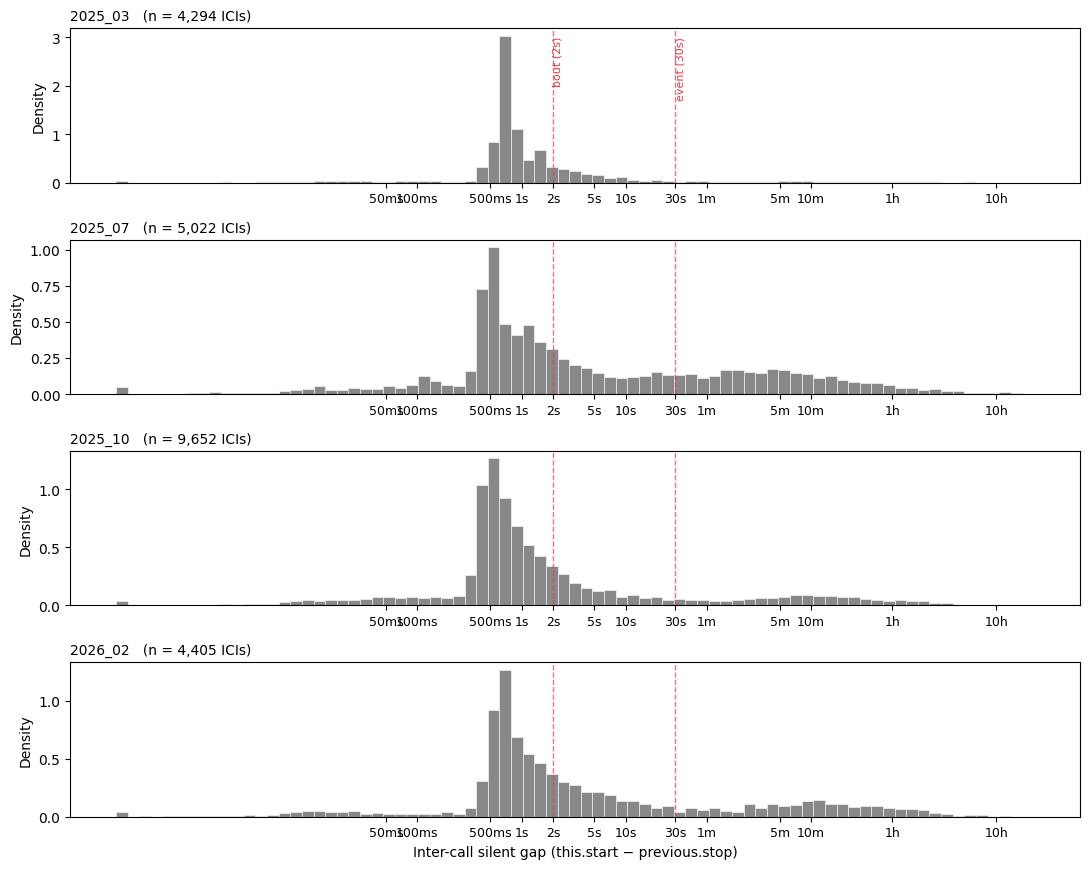

In [5]:
# Compute and tag with date_folder, then plot per-date.
prev_stop = alarm.groupby(
    ["date_folder", "exp", "assigned_location"]
)["stop_time_real"].shift(1)
alarm_ici = pd.DataFrame({
    "date_folder": alarm["date_folder"],
    "ici_s":       (alarm["start_time_real"] - prev_stop).dt.total_seconds(),
}).dropna()
alarm_ici = alarm_ici[alarm_ici["ici_s"] > 0]

# Shared bins so panels are comparable.
log_ici_all = np.log10(alarm_ici["ici_s"])
bins = np.linspace(log_ici_all.min(), log_ici_all.max(), 80)

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.2 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = alarm_ici[alarm_ici["date_folder"] == date_tag]
    if sub.empty:
        ax.text(0.5, 0.5, f"{date_tag}: no ICIs",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    log_sub = np.log10(sub["ici_s"])
    ax.hist(log_sub, bins=bins, density=True, color="#888888",
            edgecolor="white", linewidth=0.4)

    for t in [ICI_BOUT_THRESHOLD_S, ICI_EVENT_THRESHOLD_S]:
        ax.axvline(np.log10(t), color="#E63946", linestyle="--",
                   linewidth=1.0, alpha=0.7)

    ax.set_title(f"{date_tag}   (n = {len(sub):,} ICIs)", loc="left", fontsize=10)
    ax.set_ylabel("Density")
    ax.tick_params(labelbottom=True)

# Tick labels on every panel.
tick_seconds = [0.05, 0.1, 0.5, 1, 2, 5, 10, 30, 60, 300, 600, 3600, 36000]
tick_labels  = ["50ms", "100ms", "500ms", "1s", "2s", "5s", "10s", "30s",
                "1m", "5m", "10m", "1h", "10h"]
for ax in axes:
    ax.set_xticks(np.log10(tick_seconds))
    ax.set_xticklabels(tick_labels, fontsize=9)

# Reference labels only on top panel to avoid clutter.
for t, label in [
    (ICI_BOUT_THRESHOLD_S, f"bout ({ICI_BOUT_THRESHOLD_S}s)"),
    (ICI_EVENT_THRESHOLD_S, f"event ({ICI_EVENT_THRESHOLD_S}s)"),
]:
    axes[0].text(np.log10(t), axes[0].get_ylim()[1] * 0.95, f"  {label}",
                 rotation=90, fontsize=8, color="#E63946", va="top")

axes[-1].set_xlabel("Inter-call silent gap (this.start − previous.stop)")
fig.tight_layout()
save_fig(fig, "all_alarm_ici_distribution_per_date")
plt.show()


## Within-bout calling rate (period → Hz)

Within-bout start-to-start periods. `1 / median(period) = within-bout
calling rate in Hz` — directly comparable across call types.

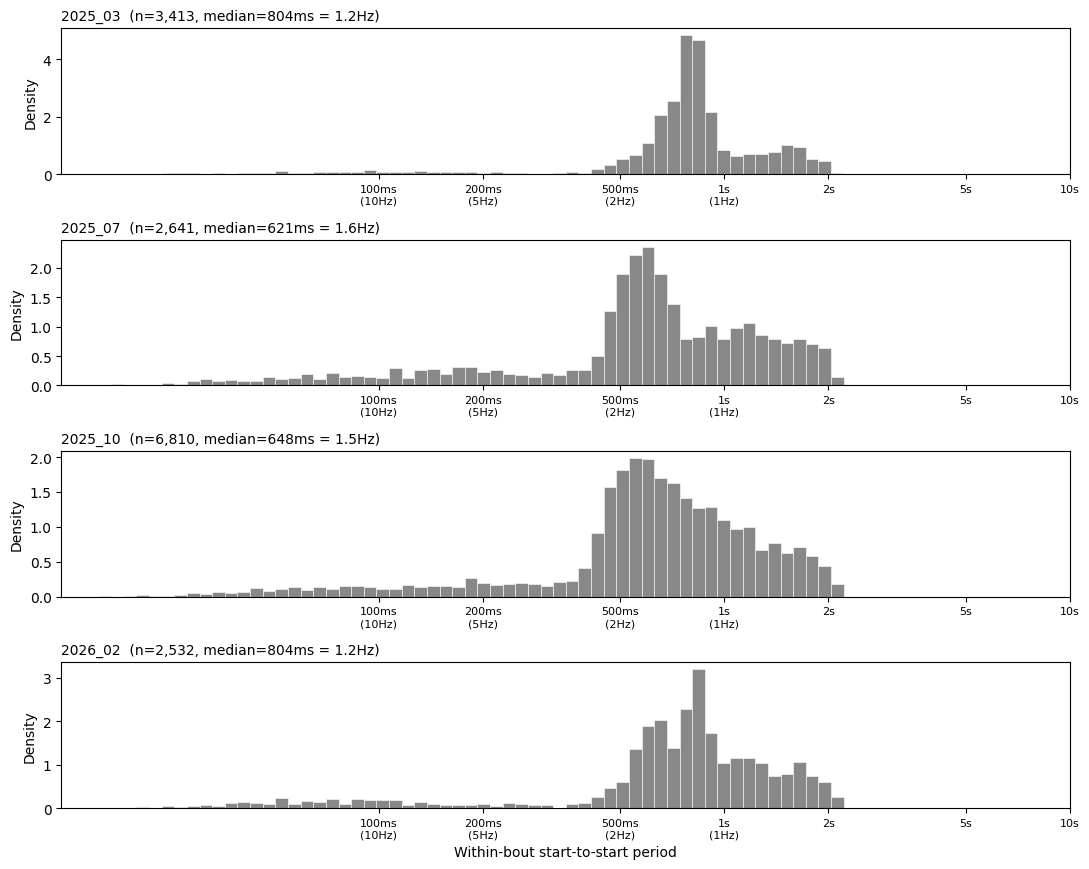


=== Median within-bout rate (start-to-start period) ===
date_folder    n  median_period_s  median_rate_hz
    2025_03 3413            0.804            1.24
    2025_07 2641            0.621            1.61
    2025_10 6810            0.648            1.54
    2026_02 2532            0.804            1.24


In [6]:
# Within-bout start-to-start periods. Same visual style as the ICI plot above.
period_with_date = pd.DataFrame({
    "date_folder":  alarm["date_folder"],
    "ici_period_s": alarm["ici_period_s"],
}).dropna()
period_with_date = period_with_date[period_with_date["ici_period_s"] > 0]

# Shared log-bins so panels are comparable. 80 bins to match the ICI plot.
log_p = np.log10(period_with_date["ici_period_s"])
bins = np.linspace(log_p.min(), log_p.max(), 80)

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.2 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)
if len(DATES_TO_PLOT) == 1:
    axes = [axes]

summary_rows = []
for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = period_with_date[period_with_date["date_folder"] == date_tag]["ici_period_s"]
    if sub.empty:
        ax.text(0.5, 0.5, f"{date_tag}: no periods",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    med_s  = sub.median()
    med_hz = 1.0 / med_s
    summary_rows.append({"date_folder": date_tag, "n": len(sub),
                         "median_period_s": round(med_s, 3),
                         "median_rate_hz": round(med_hz, 2)})

    log_sub = np.log10(sub)
    ax.hist(log_sub, bins=bins, density=True, color="#888888",
            edgecolor="white", linewidth=0.4)

    for t in [ICI_BOUT_THRESHOLD_S, ICI_EVENT_THRESHOLD_S]:
        ax.axvline(np.log10(t), color="#E63946", linestyle="--",
                   linewidth=1.0, alpha=0.7)

    ax.set_title(f"{date_tag}   (n = {len(sub):,} periods)", loc="left", fontsize=10)
    ax.set_ylabel("Density")
    ax.tick_params(labelbottom=True)

# Tick labels: time on top with Hz on bottom for the rhythm range.
tick_seconds = [0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 30, 60, 300, 600, 3600, 36000]
tick_labels  = ["50ms\n(20Hz)", "100ms\n(10Hz)", "200ms\n(5Hz)",
                "500ms\n(2Hz)", "1s\n(1Hz)", "2s", "5s", "10s",
                "30s", "1m", "5m", "10m", "1h", "10h"]
for ax in axes:
    ax.set_xticks(np.log10(tick_seconds))
    ax.set_xticklabels(tick_labels, fontsize=8)

# Reference labels only on top panel.
for t, label in [
    (ICI_BOUT_THRESHOLD_S, f"bout ({ICI_BOUT_THRESHOLD_S}s)"),
    (ICI_EVENT_THRESHOLD_S, f"event ({ICI_EVENT_THRESHOLD_S}s)"),
]:
    axes[0].text(np.log10(t), axes[0].get_ylim()[1] * 0.95, f"  {label}",
                 rotation=90, fontsize=8, color="#E63946", va="top")

axes[-1].set_xlabel("Within-bout start-to-start period (this.start − previous.start)")
fig.tight_layout()
save_fig(fig, "alarm_within_bout_period_per_date")
plt.show()

print()
print("=== Median within-bout rate (start-to-start period) ===")
print(pd.DataFrame(summary_rows).to_string(index=False))

In [7]:
iei_with_date = (
    events_meta[["date_folder", "iei_s"]]
    .dropna()
)
iei_with_date = iei_with_date[iei_with_date["iei_s"] > 0]

# Shared log-bins.
log_iei_all = np.log10(iei_with_date["iei_s"])
bins = np.linspace(log_iei_all.min(), log_iei_all.max(), 50)

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.3 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = iei_with_date[iei_with_date["date_folder"] == date_tag]["iei_s"]
    if sub.empty:
        ax.text(0.5, 0.5, f"{date_tag}: no IEIs",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    log_sub = np.log10(sub)
    ax.hist(log_sub, bins=bins, density=True, color="#888888",
            edgecolor="white", linewidth=0.4)
    ax.set_yscale("log")

    # Reference at the event threshold.
    ax.axvline(np.log10(ICI_EVENT_THRESHOLD_S), color="#E63946",
               linestyle="--", linewidth=1.0, alpha=0.7)
    if ax is axes[0]:
        ax.text(np.log10(ICI_EVENT_THRESHOLD_S),
                ax.get_ylim()[1] * 0.5,
                f" event threshold ({ICI_EVENT_THRESHOLD_S}s)",
                rotation=90, fontsize=8, color="#E63946", va="top")

    median_s = sub.median()
    ax.set_title(
        f"{date_tag}   (n = {len(sub):,} IEIs,  median = {median_s:.0f}s)",
        loc="left", fontsize=10,
    )
    ax.set_ylabel("Density (log10)")
    ax.tick_params(labelbottom=True)

# Tick labels.
tick_seconds = [30, 60, 300, 600, 3600, 36000, 86400]
tick_labels  = ["30s", "1m", "5m", "10m", "1h", "10h", "1d"]
for ax in axes:
    ax.set_xticks(np.log10(tick_seconds))
    ax.set_xticklabels(tick_labels, fontsize=9)

axes[-1].set_xlabel("Inter-event silent gap")
fig.tight_layout()
save_fig(fig, "iei_distribution_per_date")
plt.show()


KeyError: "['iei_s'] not in index"

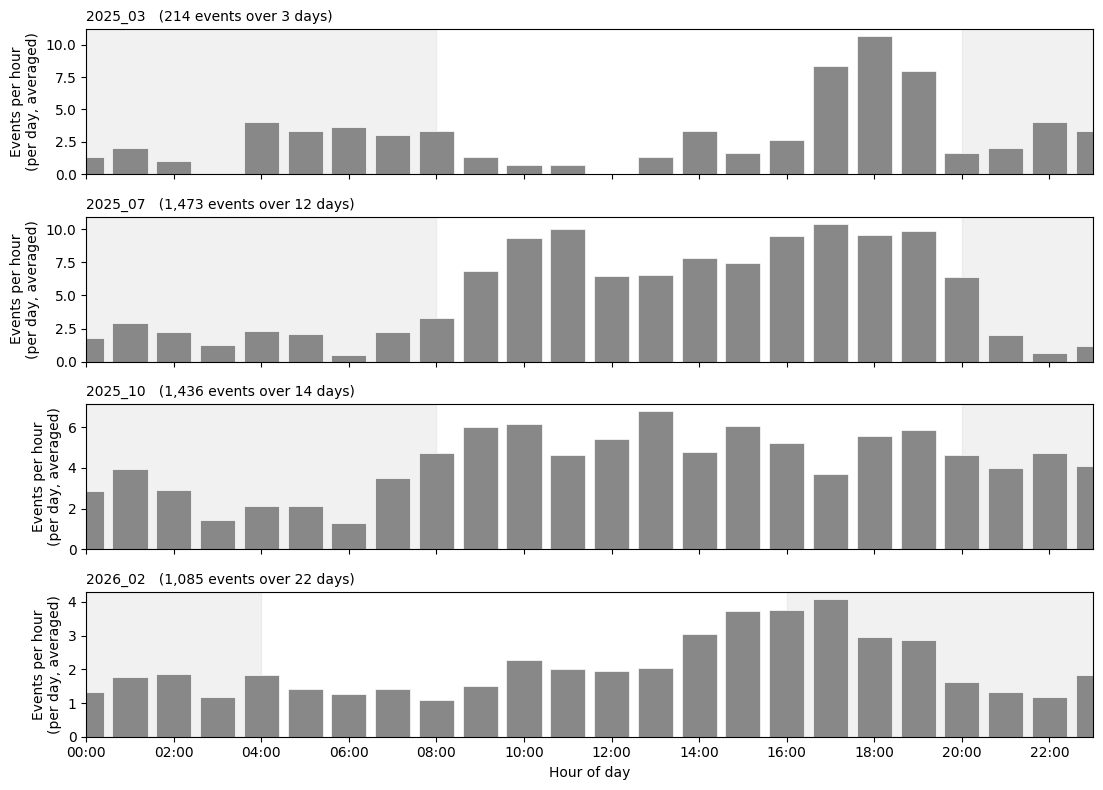

In [8]:
events_meta["hour"] = events_meta["start_time_real"].dt.hour

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.0 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = events_meta[events_meta["date_folder"] == date_tag]
    if sub.empty:
        ax.set_axis_off()
        continue

    hours = sub["hour"]
    n_days = sub["day_in_experiment"].nunique()
    counts = hours.value_counts().reindex(range(24), fill_value=0)
    rate = counts / n_days   # events per hour, averaged across days

    ax.bar(rate.index, rate.values, color="#888888",
           edgecolor="white", linewidth=0.5)

    # Light-window shading.
    light_start, light_end = LIGHT_OVERRIDES.get(date_tag, LIGHT_DEFAULT)
    if light_start < light_end:
        ax.axvspan(0, light_start, color="lightgray", alpha=0.3, zorder=0)
        ax.axvspan(light_end, 24, color="lightgray", alpha=0.3, zorder=0)
    else:
        ax.axvspan(light_end, light_start, color="lightgray", alpha=0.3, zorder=0)

    ax.set_title(
        f"{date_tag}   ({len(sub):,} events over {n_days} days)",
        loc="left", fontsize=10,
    )
    ax.set_ylabel("Events per hour\n(per day, averaged)")

ticks = range(0, 25, 2)
axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels([f"{h:02d}:00" for h in ticks])
axes[-1].set_xlabel("Hour of day")
axes[-1].set_xlim(0, 23)

fig.tight_layout()
save_fig(fig, "events_per_hour_per_date")
plt.show()


## inter event interval

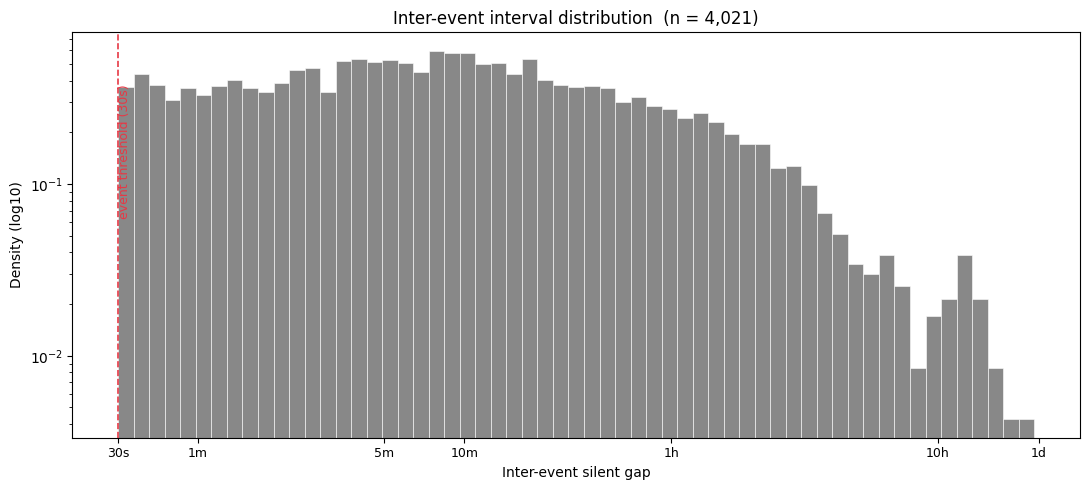

In [10]:
# Add event_stop and iei_s to events_meta.
events_meta["event_stop"] = alarm.groupby("event_id")["stop_time_real"].max()

events_meta = events_meta.sort_values(
    ["date_folder", "exp", "assigned_location", "start_time_real"]
)
prev_event_stop = events_meta.groupby(
    ["date_folder", "exp", "assigned_location"]
)["event_stop"].shift(1)
events_meta["iei_s"] = (events_meta["start_time_real"] - prev_event_stop).dt.total_seconds()

# Plot.
iei = events_meta["iei_s"].dropna()
iei = iei[iei > 0]

log_iei = np.log10(iei)
bins = np.linspace(log_iei.min(), log_iei.max(), 60)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(log_iei, bins=bins, density=True, color="#888888",
        edgecolor="white", linewidth=0.4)
ax.set_yscale("log")   # heavy tail will be more visible

ax.axvline(np.log10(ICI_EVENT_THRESHOLD_S), color="#E63946",
           linestyle="--", linewidth=1.2)
ax.text(np.log10(ICI_EVENT_THRESHOLD_S), ax.get_ylim()[1] * 0.5,
        f" event threshold ({ICI_EVENT_THRESHOLD_S}s)",
        rotation=90, fontsize=9, color="#E63946", va="top")

tick_seconds = [30, 60, 300, 600, 3600, 36000, 86400]
tick_labels  = ["30s", "1m", "5m", "10m", "1h", "10h", "1d"]
ax.set_xticks(np.log10(tick_seconds))
ax.set_xticklabels(tick_labels, fontsize=9)

ax.set_xlabel("Inter-event silent gap")
ax.set_ylabel("Density (log10)")
ax.set_title(f"Inter-event interval distribution  (n = {len(iei):,})")
fig.tight_layout()
save_fig(fig, "iei_distribution")
plt.show()


## CV


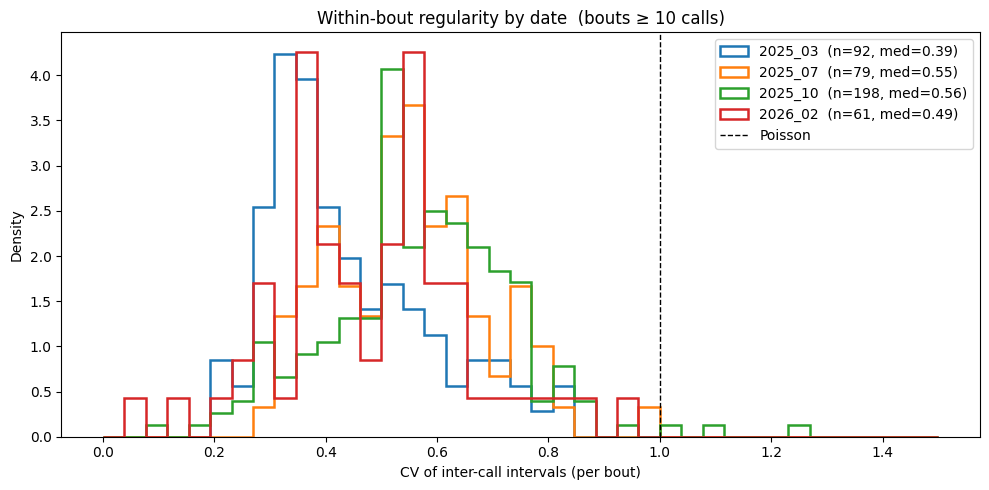

In [11]:
## Coeficient of variation (CV) of within-bout ICIs, by date.

MIN_CALLS_FOR_CV = 10

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1.5, 40)

date_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][:len(DATES_TO_PLOT)]

for date_tag, color in zip(DATES_TO_PLOT, date_colors):
    sub = bouts_meta[
        (bouts_meta["date_folder"] == date_tag)
        & (bouts_meta["bout_size"] >= MIN_CALLS_FOR_CV)
    ]["cv_ici"].dropna()
    if sub.empty:
        continue
    ax.hist(sub, bins=bins, histtype="step", linewidth=1.8, color=color,
            label=f"{date_tag}  (n={len(sub):,}, med={sub.median():.2f})",
            density=True)

ax.axvline(1.0, color="black", linestyle="--", linewidth=1.0, label="Poisson")
ax.set_xlabel("CV of inter-call intervals (per bout)")
ax.set_ylabel("Density")
ax.set_title(f"Within-bout regularity by date  (bouts ≥ {MIN_CALLS_FOR_CV} calls)")
ax.legend()
fig.tight_layout()
save_fig(fig, f"bout_within_cv_by_date_overlay_min{MIN_CALLS_FOR_CV}")
plt.show()


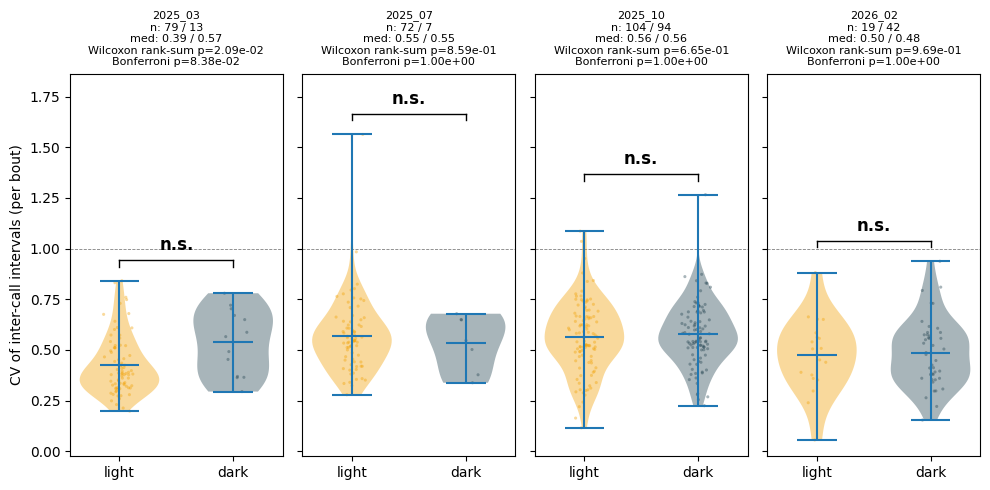

In [12]:
from scipy.stats import mannwhitneyu

LIGHT_DARK_COLORS = {"light": "#F1A208", "dark": "#264653"}
N_TESTS = len(DATES_TO_PLOT)


def stars(p):
    if np.isnan(p):  return "—"
    if p < 0.001:    return "***"
    if p < 0.01:     return "**"
    if p < 0.05:     return "*"
    return "n.s."


fig, axes = plt.subplots(
    1, len(DATES_TO_PLOT),
    figsize=(2.5 * len(DATES_TO_PLOT), 5),
    sharey=True,
)
global_top = 0.0

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = bouts_meta[
        (bouts_meta["date_folder"] == date_tag)
        & (bouts_meta["bout_size"] >= MIN_CALLS_FOR_CV)
        & bouts_meta["cv_ici"].notna()
    ]

    light_vals = sub[sub["light_dark"] == "light"]["cv_ici"].values
    dark_vals  = sub[sub["light_dark"] == "dark"]["cv_ici"].values

    if len(light_vals) >= 3 and len(dark_vals) >= 3:
        _, p_raw = mannwhitneyu(light_vals, dark_vals)
        p_bonf = min(p_raw * N_TESTS, 1.0)
    else:
        p_raw = p_bonf = float("nan")

    data = {"light": light_vals, "dark": dark_vals}

    if all(len(v) > 0 for v in data.values()):
        parts = ax.violinplot(
            list(data.values()),
            positions=[0, 1], showmeans=True, widths=0.7,
        )
        for pc, color in zip(parts["bodies"], LIGHT_DARK_COLORS.values()):
            pc.set_facecolor(color)
            pc.set_alpha(0.4)

    rng = np.random.default_rng(0)
    for x, (cls, vals) in zip([0, 1], data.items()):
        if len(vals) == 0:
            continue
        jitter = rng.normal(0, 0.06, len(vals))
        ax.scatter(x + jitter, vals,
                   s=5, alpha=0.4, color=LIGHT_DARK_COLORS[cls],
                   edgecolor="none")

    # Significance bracket.
    top = max(
        light_vals.max() if len(light_vals) else 0,
        dark_vals.max()  if len(dark_vals)  else 0,
    )
    bracket_y = top + 0.10
    tick_h    = 0.03
    ax.plot([0, 1], [bracket_y, bracket_y], color="black", linewidth=1)
    ax.plot([0, 0], [bracket_y - tick_h, bracket_y], color="black", linewidth=1)
    ax.plot([1, 1], [bracket_y - tick_h, bracket_y], color="black", linewidth=1)
    ax.text(0.5, bracket_y + 0.03, stars(p_bonf),
            ha="center", va="bottom", fontsize=12, fontweight="bold")

    global_top = max(global_top, bracket_y + 0.2)

    ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.6, zorder=0)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["light", "dark"])
    ax.set_title(
        f"{date_tag}\n"
        f"n: {len(light_vals)} / {len(dark_vals)}\n"
        f"med: {np.median(light_vals) if len(light_vals) else float('nan'):.2f} / "
        f"{np.median(dark_vals) if len(dark_vals) else float('nan'):.2f}\n"
        f"Wilcoxon rank-sum p={p_raw:.2e}\n"
        f"Bonferroni p={p_bonf:.2e}",
        fontsize=8,
    )

axes[0].set_ylabel("CV of inter-call intervals (per bout)")
axes[0].set_ylim(top=global_top)

fig.tight_layout()
save_fig(fig, "bout_cv_violin_light_vs_dark")
plt.show()


## Reduction of calls vs time

In [5]:
duration_by_position = alarm.pivot(
    index="bout_id", columns="position", values="duration_sec"
)
print(f"{duration_by_position.shape[0]:,} bouts × {duration_by_position.shape[1]} max positions")
duration_by_position.head()

8,164 bouts × 293 max positions


position,1,2,3,4,5,6,7,8,9,10,...,284,285,286,287,288,289,290,291,292,293
bout_id,,,,,,,,,,,,,,,,,,,,,
1,0.042112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.022272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.084088,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.234872,0.198016,0.187896,0.15872,0.145656,0.1102,0.12224,0.148736,0.100864,0.099712,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.092920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
def get_pair(last_pos, *, location=None, date_folder=None, min_size=None):
    """Return a per-bout DataFrame [first, last, diff, ratio, bout_size]
    for the requested slice."""
    keep = bouts_meta
    if location is not None:
        keep = keep[keep["assigned_location"] == location]
    if date_folder is not None:
        keep = keep[keep["date_folder"] == date_folder]
    if min_size is None:
        min_size = last_pos
    keep = keep[keep["bout_size"] >= min_size]

    if keep.empty:
        return None

    sub_mat = duration_by_position.loc[keep.index]
    pair = pd.concat({"first": sub_mat[1], "last": sub_mat[last_pos]}, axis=1).dropna()
    pair = pair[pair["first"] > 0]                # avoid div-by-zero
    pair["diff"]      = pair["first"] - pair["last"]
    pair["ratio"]     = pair["last"] / pair["first"]
    pair["bout_size"] = bouts_meta.loc[pair.index, "bout_size"]
    return pair

In [7]:
LAST_POS = 7
TOP_N = 10

pair = get_pair(LAST_POS, location="underground")
#pair.head(10)
sorted_bouts = (pair.join(bouts_meta[["date_folder", "exp", "file_num", "start_time_file_sec","start_time_real","light_dark"]]).sort_values("ratio", ascending=True))

print(f"Top {TOP_N} bouts by (first − call {LAST_POS}) duration drop:")
print(sorted_bouts.head(TOP_N).to_string())


Top 10 bouts by (first − call 7) duration drop:
            first      last      diff     ratio  bout_size date_folder  exp  file_num  start_time_file_sec            start_time_real light_dark
bout_id                                                                                                                                         
5151     0.229120  0.018944  0.210176  0.082682        128     2025_10  340       192           132.811776 2025-10-15 13:00:03.811776      light
5874     0.214912  0.023544  0.191368  0.109552         12     2025_10  343       133            42.870144 2025-10-18 08:11:06.870144      light
803      0.164600  0.019584  0.145016  0.118979         13     2025_03  237        76           204.609536 2025-03-22 19:55:12.609536      light
5985     0.235640  0.029560  0.206080  0.125446          9     2025_10  343       248           222.168064 2025-10-18 19:44:06.168064      light
7328     0.202232  0.025600  0.176632  0.126587         11     2026_02  506       

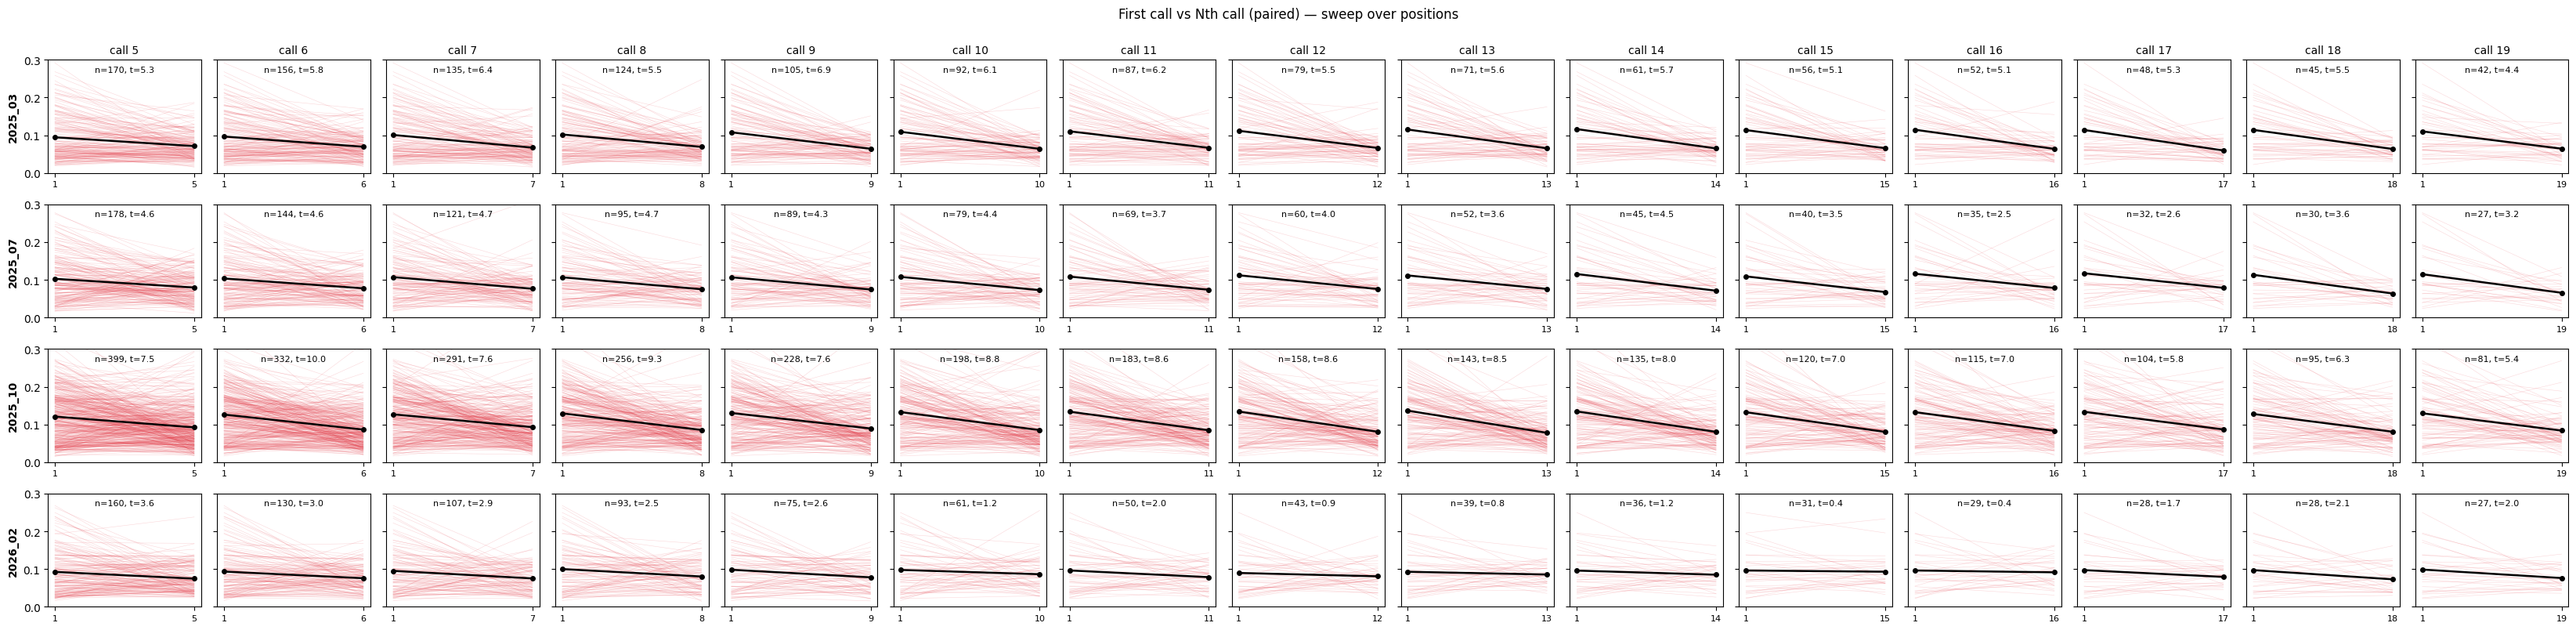

In [14]:
SWEEP_POSITIONS = list(range(5, 20))   # 5, 6, 7, 8, 9, 10

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), len(SWEEP_POSITIONS),
    figsize=(2.2 * len(SWEEP_POSITIONS), 2.0 * len(DATES_TO_PLOT)),
    sharey=True,   # each date's row shares y-scale across positions
)

for r, date_tag in enumerate(DATES_TO_PLOT):
    for c, last_pos in enumerate(SWEEP_POSITIONS):
        ax = axes[r, c]

        sub = alarm[
            (alarm["date_folder"] == date_tag)
            & (alarm["bout_size"] >= last_pos)
        ]
        if sub.empty:
            ax.set_axis_off()
            continue

        mat = sub.pivot(index="bout_id", columns="position", values="duration_sec")
        pair = pd.concat({"first": mat[1], "last": mat[last_pos]}, axis=1).dropna()

        if len(pair) < 5:
            ax.text(0.5, 0.5, f"n={len(pair)}",
                    ha="center", va="center", transform=ax.transAxes, fontsize=8)
            ax.set_xticks([])
            continue

        t_stat, p_val = stats.ttest_rel(pair["first"], pair["last"])

        ax.plot([0, 1],
                np.vstack([pair["first"].values, pair["last"].values]),
                color="#E63946", alpha=0.2, linewidth=0.4)
        ax.plot([0, 1],
                [pair["first"].mean(), pair["last"].mean()],
                color="black", linewidth=1.8, marker="o", markersize=4)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["1", str(last_pos)], fontsize=8)

        if r == 0:
            ax.set_title(f"call {last_pos}", fontsize=10)
        ax.text(0.5, 0.95,
                f"n={len(pair)}, t={t_stat:.1f}",
                transform=ax.transAxes, ha="center", va="top", fontsize=8)

        if c == 0:
            ax.set_ylabel(f"{date_tag}", fontweight="bold")
        ax.set_ylim([0, 0.3])
fig.suptitle("First call vs Nth call (paired) — sweep over positions",
             y=1.0, fontsize=12)
fig.tight_layout()
save_fig(fig, "alarm_first_vs_nth_sweep")
plt.show()


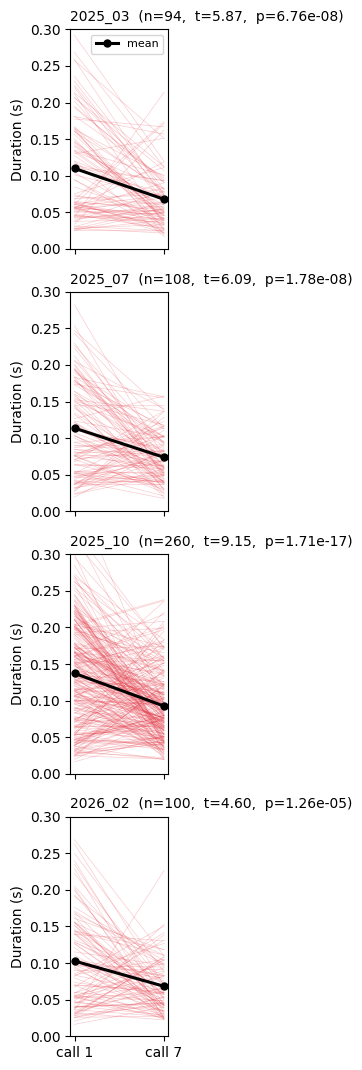

In [ ]:
from scipy import stats

   # change this to compare call 1 vs call N

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(2, 2.7 * len(DATES_TO_PLOT)),
    sharex=True,
    sharey=True,
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = alarm[
        (alarm["date_folder"] == date_tag)
        & (alarm["bout_size"] >= LAST_POS)
        & (alarm["assigned_location"] == "underground")
    ]
    if sub.empty:
        ax.text(0.5, 0.5, "no qualifying bouts",
                ha="center", va="center", transform=ax.transAxes)
        continue

    mat = sub.pivot(index="bout_id", columns="position", values="duration_sec")

    # Pull the two columns we care about, align on bout_id, drop any NaN pair.
    pair = pd.concat({"first": mat[1], "last": mat[LAST_POS]}, axis=1).dropna()

    # Paired t-test: each first-call vs its own bout's Nth-call.
    t_stat, p_val = stats.ttest_rel(pair["first"], pair["last"])

    # Slopegraph: one line per bout, from "first" to "last".
    ax.plot(
        [0, 1],
        np.vstack([pair["first"].values, pair["last"].values]),
        color="#E63946", alpha=0.25, linewidth=0.5,
    )

    # Mean overlay so the population shift pops out.
    ax.plot([0, 1], [pair["first"].mean(), pair["last"].mean()],
            color="black", linewidth=2.2, marker="o", markersize=5,
            label="mean", zorder=10)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["call 1", f"call {LAST_POS}"])
    ax.set_ylim([0,0.3])
    ax.set_ylabel("Duration (s)")
    ax.set_title(
        f"{date_tag}  (n={len(pair)},  t={t_stat:.2f},  p={p_val:.2e})",
        loc="left", fontsize=10,
    )

axes[0].legend(loc="upper right", fontsize=8)
fig.tight_layout()
save_fig(fig, f"alarm_first_vs_call{LAST_POS}_paired")
plt.show()

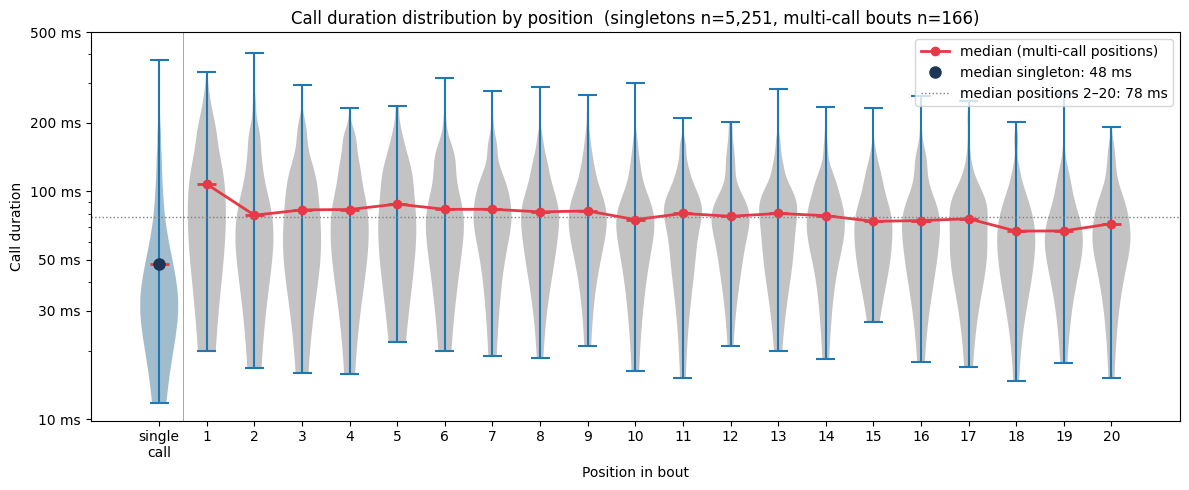

In [18]:
MAX_POS = 20

# Multi-call bouts that reach MAX_POS — same as before.
multi = alarm[alarm["bout_size"] >= MAX_POS]
multi = multi[multi["position"] <= MAX_POS]

# Singletons (bout_size == 1).
single_durs = alarm.loc[alarm["bout_size"] == 1, "duration_sec"].values

# Build per-position arrays. Index 0 = singletons; 1–MAX_POS = multi-call positions.
data = [single_durs] + [
    multi[multi["position"] == p]["duration_sec"].values
    for p in range(1, MAX_POS + 1)
]
positions = list(range(0, MAX_POS + 1))   # x-coordinate for each violin
n_multi = len(data[1])

fig, ax = plt.subplots(figsize=(12, 5))

# Singleton violin in a different color so it reads as a different category.
parts = ax.violinplot(data, positions=positions,
                      showmeans=False, showmedians=True, widths=0.8)
for i, pc in enumerate(parts["bodies"]):
    if i == 0:
        pc.set_facecolor("#457B9D")   # singletons in blue
    else:
        pc.set_facecolor("#888888")   # multi-call in grey
    pc.set_alpha(0.5)
parts["cmedians"].set_color("#E63946")
parts["cmedians"].set_linewidth(2)

# Median trajectory only on the multi-call positions.
medians_multi = [np.median(d) for d in data[1:]]
ax.plot(positions[1:], medians_multi, "o-", color="#E63946", linewidth=2,
        markersize=6, label="median (multi-call positions)")

# Singleton median as a reference dot.
ax.plot([0], [np.median(single_durs)], "o", color="#1D3557", markersize=8,
        label=f"median singleton: {np.median(single_durs)*1000:.0f} ms")

# Stable-rhythm reference line.
later_concat = np.concatenate(data[2:])
floor_median = np.median(later_concat)
ax.axhline(floor_median, color="grey", linestyle=":", linewidth=1,
           label=f"median positions 2–{MAX_POS}: {floor_median*1000:.0f} ms")

# Vertical separator between singleton and multi-call regimes.
ax.axvline(0.5, color="black", linestyle="-", linewidth=0.6, alpha=0.4)

ax.set_yscale("log")
ax.set_xlabel("Position in bout")
ax.set_ylabel("Call duration")
ax.set_title(
    f"Call duration distribution by position  "
    f"(singletons n={len(single_durs):,}, multi-call bouts n={n_multi:,})"
)
ax.legend(loc="upper right")

# X-tick labels: "single call" + position numbers.
ax.set_xticks(positions)
ax.set_xticklabels(["single\ncall"] + [str(p) for p in range(1, MAX_POS + 1)])

# Y-axis in real-time units.
ytick_s = [0.01, 0.03, 0.05, 0.1, 0.2, 0.5]
ax.set_yticks(ytick_s)
ax.set_yticklabels([f"{t*1000:.0f} ms" if t < 1 else f"{t:.1f} s" for t in ytick_s])

fig.tight_layout()
save_fig(fig, "duration_by_position_with_singletons")
plt.show()
